In [1]:
import pandas as pd
import numpy as np
import os
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

### ---------------------------------------------------------
### Step 1: 데이터 로드 및 시계열 특징 추출
### ---------------------------------------------------------

In [5]:
master_df = pd.read_csv('D:/AI_Study/GitHub/Battery/Master_DOE_1200.csv')
path = 'D:/AI_Study/GitHub/Battery/데이터셋/'
processed_data = []

In [6]:
# 6-Dimension 파라미터 리스트 정의
p_columns = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']

print("데이터 분석 및 특징 추출 시작...")

데이터 분석 및 특징 추출 시작...


In [7]:
for i, row in master_df.iterrows():
    file_path = os.path.join(path, f'ML_DATA_Extract_Row_{i}.csv')
    if os.path.exists(file_path):
        df_ts = pd.read_csv(file_path)
        df_ts.columns = df_ts.columns.str.strip()
        
        # 특징 추출
        max_sy = df_ts['Die_SY_Max'].abs().max()
        warp_vel = np.diff(df_ts['WarpMax']).mean() if len(df_ts) > 1 else 0
        heat_load = df_ts['TempBase'].sum()

        features = row.to_dict()
        features.update({
            'TS_Warp_Velocity': warp_vel,
            'TS_Heat_Load': heat_load,
            'Target_Max_Peak': max_sy 
        })
        processed_data.append(features)

df_enhanced = pd.DataFrame(processed_data)

### ---------------------------------------------------------
### Step 2: 6-Dimension Geometric Parameter 범위 정의 및 샘플링
### ---------------------------------------------------------

In [9]:
# 깃허브 정의서에 따른 각 파라미터의 실제 탐색 범위(Min, Max) 추출
p_bounds = {col: (df_enhanced[col].min(), df_enhanced[col].max()) for col in p_columns}

print("\n--- 정의된 파라미터 탐색 범위 (Boundary) ---")

for p, (p_min, p_max) in p_bounds.items():
    print(f"{p}: {p_min:.2f} ~ {p_max:.2f}")

def generate_valid_samples(n, bounds):
    """정의된 범위를 엄격히 준수하는 몬테카를로 샘플링"""
    samples = pd.DataFrame()
    for p_name, (p_min, p_max) in bounds.items():
        # 균등 분포(Uniform)에서 범위 내 난수 생성
        samples[p_name] = np.random.uniform(p_min, p_max, n)
    return samples

# 10만 개의 가상 설계 조합(P1~P6) 생성
n_virtual = 100000
virtual_input = generate_valid_samples(n_virtual, p_bounds)

# 시계열 파생 변수는 기존 데이터의 평균값으로 보정 (학습 일관성 유지)
virtual_input['TS_Warp_Velocity'] = df_enhanced['TS_Warp_Velocity'].mean()
virtual_input['TS_Heat_Load'] = df_enhanced['TS_Heat_Load'].mean()


--- 정의된 파라미터 탐색 범위 (Boundary) ---
P1: 0.80 ~ 1.10
P2: 0.05 ~ 0.09
P3: 0.60 ~ 0.72
P4: 0.10 ~ 0.30
P5: 1.20 ~ 1.80
P6: 0.04 ~ 0.08


### ---------------------------------------------------------
### Step 3: 모델 학습 및 앙상블 예측 (Data Augmentation)
### ---------------------------------------------------------

In [10]:
X = df_enhanced.drop(columns=['Target_Max_Peak'])
y = df_enhanced['Target_Max_Peak']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 모델 정의
models = {
    "XGBoost": xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, random_state=42),
    "CatBoost": CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=6, verbose=0, random_state=42)
}

# 학습 및 예측
preds = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds[name] = model.predict(virtual_input) # 10만 개 가상 데이터에 대해 예측

# 앙상블 결과 (평균)
virtual_input['Augmented_Max_Peak'] = (preds["XGBoost"] + preds["CatBoost"]) / 2

print(f"\n✅ {n_virtual}개의 유효 범위 내 가상 데이터 생성 완료!")


✅ 100000개의 유효 범위 내 가상 데이터 생성 완료!


### ---------------------------------------------------------
### Step 4: 시각화 (범위 준수 여부 및 결과 분포 확인)
### ---------------------------------------------------------

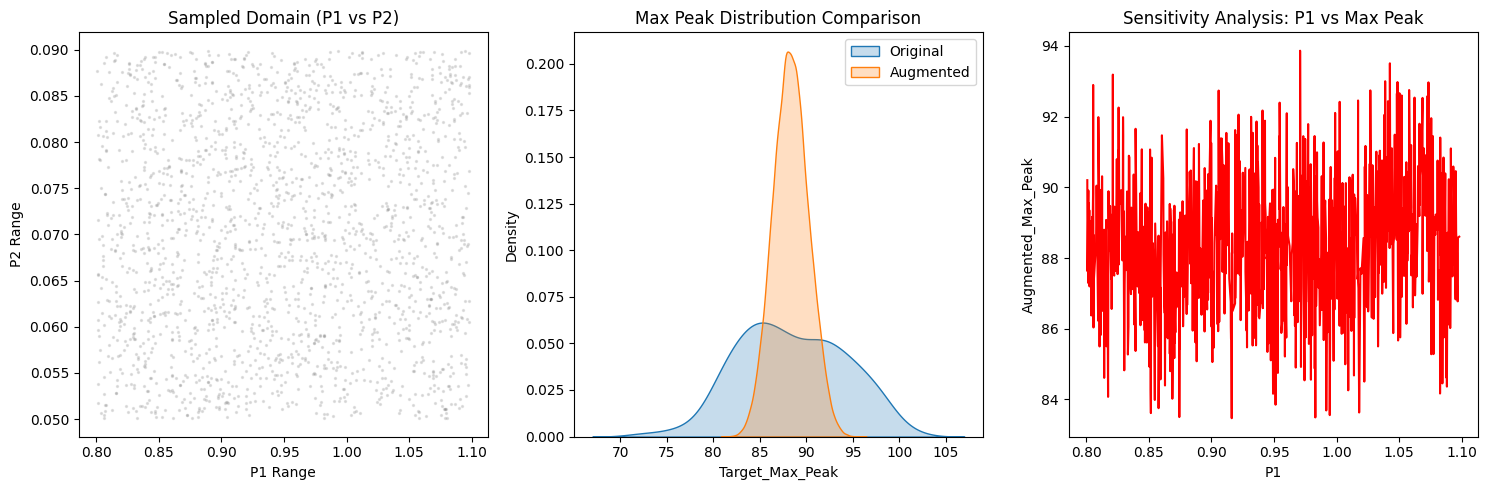

In [11]:
plt.figure(figsize=(15, 5))

# 4-1. P1 vs P2 샘플링 분포 (정의된 사각형 범위를 채우는지 확인)
plt.subplot(1, 3, 1)
plt.scatter(virtual_input['P1'].sample(2000), virtual_input['P2'].sample(2000), alpha=0.2, s=2, color='gray')
plt.title("Sampled Domain (P1 vs P2)")
plt.xlabel("P1 Range")
plt.ylabel("P2 Range")

# 4-2. 가상 데이터의 예측 결과 분포
plt.subplot(1, 3, 2)
sns.kdeplot(df_enhanced['Target_Max_Peak'], label='Original', fill=True)
sns.kdeplot(virtual_input['Augmented_Max_Peak'], label='Augmented', fill=True)
plt.title("Max Peak Distribution Comparison")
plt.legend()

# 4-3. 중요 파라미터(P1)에 따른 예측값 변화
plt.subplot(1, 3, 3)
sns.lineplot(data=virtual_input.sample(1000), x='P1', y='Augmented_Max_Peak', color='red')
plt.title("Sensitivity Analysis: P1 vs Max Peak")

plt.tight_layout()
plt.show()